## Importing necessary libraries

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Defining constants and file paths 

In [2]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

base_dir = './dataset'
train_dir = os.path.join(base_dir, 'train/train')
val_dir = os.path.join(base_dir, 'Sample_fake_images/Sample_fake_images')
test_dir = os.path.join(base_dir, 'test/test')

## Evaluating the model on the test dataset

In [9]:
def evaluate_on_test_set(model, test_gen):
    print("Evaluating model on the test dataset...")
    test_loss, test_accuracy = model.evaluate(test_gen)

    print("-" * 30)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Loss:     {test_loss:.4f}")
    print("-" * 30)

In [ ]:
train_datagen_x = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.20
)

test_datagen_x = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_x = train_datagen_x.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    subset='training'
)

validation_generator_x = train_datagen_x.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    subset='validation'
)

test_generator_x = test_datagen_x.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 384 images belonging to 2 classes.
Found 95 images belonging to 2 classes.
Found 499 images belonging to 2 classes.


## Training the Xception model for image detection

In [6]:
# Load pre-trained Xception without the top layer
xception_base = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers for Phase 1 of Transfer Learning
xception_base.trainable = False

# Attach Custom Head
x = xception_base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

xception_model = Model(inputs=xception_base.input, outputs=predictions)

# Compile
xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print confirmation
print("Xception Model successfully compiled and ready for training!")

Xception Model successfully compiled and ready for training!


In [23]:
xception_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_12[0][0]    

 Total params: 21,921,321 (83.62 MB)

 Trainable params: 1,054,721 (4.02 MB)

 Non-trainable params: 20,866,600 (79.60 MB)

In [24]:
history = xception_model.fit(
    train_generator_x,                       # <--- FIXED
    epochs=20,
    validation_data=validation_generator_x,  # <--- FIXED
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6224 - loss: 0.9497 - val_accuracy: 0.4632 - val_loss: 0.8028 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7630 - loss: 0.6089 - val_accuracy: 0.5579 - val_loss: 0.7627 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7917 - loss: 0.4736 - val_accuracy: 0.7789 - val_loss: 0.5207 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7812 - loss: 0.4873 - val_accuracy: 0.7579 - val_loss: 0.6043 - learning_rate: 2.0000e-04
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8021 - loss: 0.4911 - val_accuracy: 0.7474 - val_loss: 0.5651 - learning_rate: 2.0000e-04


In [10]:
evaluate_on_test_set(xception_model, test_generator_x)

Evaluating model on the test dataset...


/Users/skakibahammed/code_playground/Model_Repo/image_detect/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7635 - loss: 0.5864
------------------------------
Test Accuracy: 76.35%
Test Loss:     0.5864
------------------------------


## Saving the model

In [8]:
xception_model.save('xception_deepfake_base.keras')
print("Model saved successfully as 'xception_deepfake_base.keras'")

Model saved successfully as 'xception_deepfake_base.keras'


## Classification Report for this model

In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Evaluating Xception Model on Test Set...")

test_generator_x.reset()

preds = xception_model.predict(test_generator_x, steps=len(test_generator_x), verbose=1)

all_predictions = (preds > 0.5).astype(int).flatten()

all_labels = test_generator_x.classes

class_labels_dict = test_generator_x.class_indices
target_names = [name for name, index in sorted(class_labels_dict.items(), key=lambda x: x[1])]

unique_true, counts_true = np.unique(all_labels, return_counts=True)
print(f"\nTrue labels in test set: {dict(zip(unique_true, counts_true))}")

unique_preds, counts_preds = np.unique(all_predictions, return_counts=True)
print(f"Model predictions: {dict(zip(unique_preds, counts_preds))}")

Evaluating Xception Model on Test Set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step

True labels in test set: {np.int32(0): np.int64(389), np.int32(1): np.int64(110)}
Model predictions: {np.int64(0): np.int64(469), np.int64(1): np.int64(30)}



Classification Report:
              precision    recall  f1-score   support

        fake       0.79      0.95      0.86       389
        real       0.37      0.10      0.16       110

    accuracy                           0.76       499
   macro avg       0.58      0.53      0.51       499
weighted avg       0.70      0.76      0.71       499

Accuracy: 76.35%



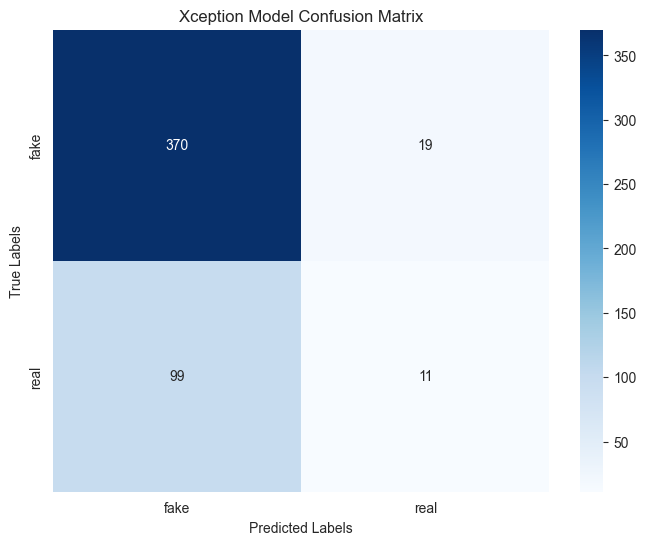

In [14]:
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=target_names, zero_division=0))

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Xception Model Confusion Matrix')
plt.show()